In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import m_e, h
from astropy.coordinates import Distance

from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton
from agnpy.time_evolution.time_evolution import TimeEvolution, synchrotron_loss, ssc_loss
from agnpy.utils.plot import plot_sed
from agnpy.bsm.liv import LIVdelay

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# set the quantities defining the blob and the electron distribution
R_b = 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
W_e = 1e48 * u.erg # total energy in electrons
z = Distance(1e27, unit=u.cm).z
delta_D = 10
Gamma = 10
B = 1 * u.G

# initial electron distribution
n_e_initial = PowerLaw.from_total_energy(
    W_e,
    V_b,
    p=2.8,
    gamma_min=1e2,
    gamma_max=1e7,
    mass=m_e,
)

In [3]:
# define the blob and the energy loss mechanism
blob = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e_initial)
synch = SynchrotronSelfCompton(blob)


# define the blob and the energy loss mechanism for LIV
blob_posliv = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e_initial)
synch_posliv = SynchrotronSelfCompton(blob_posliv)

# define the blob and the energy loss mechanism for LIV
blob_negliv = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e_initial)
synch_negliv = SynchrotronSelfCompton(blob_negliv)

# define LIVdelay classes
nu_syn = np.logspace(21, 28, 100) * u.Hz
E_syn = nu_syn*h.to("GeV/Hz")

reference_0liv = LIVdelay(lambda_liv=0*u.s/u.TeV, n_liv=1, blob=blob, nu_syn=nu_syn, synch=synch, time_step=10*u.min, steps=30)
with_posliv = LIVdelay(lambda_liv=200*u.s/u.TeV, n_liv=1, blob=blob_posliv, nu_syn=nu_syn, synch=synch_posliv, time_step=10*u.min, steps=30)
with_negliv = LIVdelay(lambda_liv=-200*u.s/u.TeV, n_liv=1, blob=blob_negliv, nu_syn=nu_syn, synch=synch_negliv, time_step=10*u.min, steps=30)

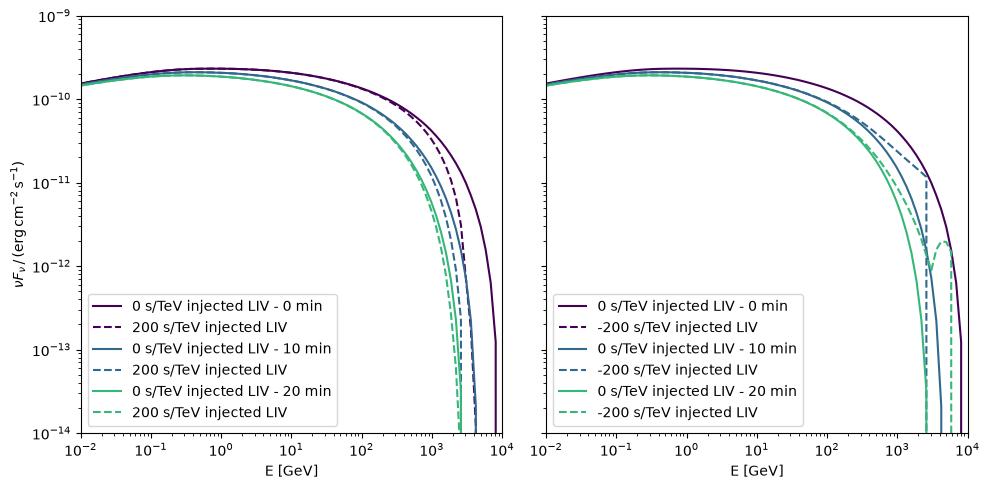

In [4]:
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(1,2, sharex=True, sharey=True, figsize=(10,5))

for i in range(3):
    zeroliv = reference_0liv.evaluate(i*10*u.min)
    posliv = with_posliv.evaluate(i*10*u.min)
    negliv = with_negliv.evaluate(i*10*u.min)

    # Positive LIV
    ax[0].plot(
        E_syn,
        zeroliv,
        label="0 s/TeV injected LIV - {:.0f}".format(i*10*u.min),
        color=cmap(i / 3)
    )
    ax[0].plot(
        E_syn,
        posliv,
        '--',
        label=r"200 s/TeV injected LIV",
        color=cmap(i / 3)
    )

    # Negative LIV
    ax[1].plot(
        E_syn,
        zeroliv,
        label="0 s/TeV injected LIV - {:.0f}".format(i*10*u.min),
        color=cmap(i / 3)
    )
    ax[1].plot(
        E_syn,
        negliv,
        '--',
        label=r"-200 s/TeV injected LIV",
        color=cmap(i / 3)
    )


ax[0].set_xscale('log')
ax[0].set_xlim([1e-2, 1e4]) # GeV
ax[0].set_xlabel('E [GeV]')
ax[1].set_xlabel('E [GeV]')

ax[0].set_yscale('log')
ax[0].set_ylabel(r"$\nu F_{\nu}\,/\,(\mathrm{erg}\,\mathrm{cm}^{-2}\,\mathrm{s}^{-1})$")
ax[0].set_ylim([1e-14, 1e-9])

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()